# Deutsch & Deutsch-Jozsa Algorithm
### Quantum advantage with a single query

**Course:** UCL Quantum Computing · **Prerequisites:** qubits, Hadamard, phase kickback

---

## The Problem: Constant or Balanced?

You are given a black-box function $f:\{0,1\}^n \to \{0,1\}$ — an **oracle** you can query.
The function is promised to be either:
- **Constant**: $f(x) = 0$ for all $x$, or $f(x) = 1$ for all $x$.
- **Balanced**: exactly half the inputs map to 0 and half to 1.

**Goal**: determine which case you are in, using as few queries as possible.

**Classical cost**: in the worst case you must query $2^{n-1}+1$ inputs — more than half.
**Quantum cost**: **one query**, always. This is the first proven quantum speedup over classical computation.


## The Oracle Model

The quantum oracle is a unitary $U_f$ acting on an input register and an ancilla qubit:

$$U_f |x\rangle |y\rangle = |x\rangle |y \oplus f(x)\rangle$$

where $\oplus$ is XOR. The oracle encodes $f(x)$ into the ancilla without disturbing the input.
If we set the ancilla to $|-\rangle = \frac{1}{\sqrt{2}}(|0\rangle - |1\rangle)$, something special happens — **phase kickback**:

$$U_f |x\rangle |-\rangle = (-1)^{f(x)} |x\rangle |-\rangle$$

The $(-1)^{f(x)}$ phase is "kicked back" onto the input register. The ancilla is unchanged.
This is the central trick: the oracle writes its answer as a **phase**, not a bit-flip.


## Deutsch's Algorithm (n = 1)

**Circuit:**

$$|0\rangle|1\rangle \xrightarrow{H \otimes H} \frac{1}{2}(|0\rangle+|1\rangle)(|0\rangle-|1\rangle) \xrightarrow{U_f} \frac{(-1)^{f(0)}}{2}\bigl(|0\rangle + (-1)^{f(0)\oplus f(1)}|1\rangle\bigr)(|0\rangle-|1\rangle) \xrightarrow{H\otimes I} \cdots$$

After the final Hadamard on qubit 0:
- **Constant** ($f(0) = f(1)$): $(-1)^{f(0)} \oplus (-1)^{f(1)} = $ same phase → qubit 0 is $|0\rangle$
- **Balanced** ($f(0) \neq f(1)$): opposite phases → qubit 0 is $|1\rangle$

**One query determines everything via interference.**


In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'figure.dpi': 120, 'font.size': 11})

simulator = AerSimulator()
print("Qiskit + Aer ready ✓")


Qiskit + Aer ready ✓


In [2]:
# ── Oracle builder ─────────────────────────────────────────────────
def deutsch_oracle(oracle_type):
    """
    Returns a 2-qubit circuit implementing the Deutsch oracle.
    Qubit 0 = input, qubit 1 = ancilla.
    oracle_type: 'constant_0' | 'constant_1' | 'balanced_id' | 'balanced_not'
    """
    qc = QuantumCircuit(2, name=f"Oracle ({oracle_type})")
    if oracle_type == 'constant_0':
        pass                          # f(x) = 0: do nothing
    elif oracle_type == 'constant_1':
        qc.x(1)                       # f(x) = 1: flip ancilla
    elif oracle_type == 'balanced_id':
        qc.cx(0, 1)                   # f(x) = x: CNOT
    elif oracle_type == 'balanced_not':
        qc.cx(0, 1)                   # f(x) = NOT x: CNOT + X
        qc.x(1)
    return qc

# ── Deutsch circuit builder ────────────────────────────────────────
def deutsch_circuit(oracle_type):
    qc = QuantumCircuit(2, 1)

    # Initialise ancilla to |1⟩
    qc.x(1)
    qc.barrier()

    # Apply H to both qubits  →  |+⟩|−⟩
    qc.h([0, 1])
    qc.barrier()

    # Apply oracle  →  phase kickback writes f into phase
    oracle = deutsch_oracle(oracle_type)
    qc.compose(oracle, inplace=True)
    qc.barrier()

    # Apply H to input qubit  →  interference reveals constant/balanced
    qc.h(0)
    qc.barrier()

    # Measure input qubit
    qc.measure(0, 0)
    return qc

# Draw all four oracles
for otype in ['constant_0', 'constant_1', 'balanced_id', 'balanced_not']:
    qc = deutsch_circuit(otype)
    print(f"\n─── Oracle: {otype} ───")
    print(qc.draw('text'))



─── Oracle: constant_0 ───
           ░ ┌───┐ ░  ░ ┌───┐ ░ ┌─┐
q_0: ──────░─┤ H ├─░──░─┤ H ├─░─┤M├
     ┌───┐ ░ ├───┤ ░  ░ └───┘ ░ └╥┘
q_1: ┤ X ├─░─┤ H ├─░──░───────░──╫─
     └───┘ ░ └───┘ ░  ░       ░  ║ 
c: 1/════════════════════════════╩═
                                 0 

─── Oracle: constant_1 ───
           ░ ┌───┐ ░       ░ ┌───┐ ░ ┌─┐
q_0: ──────░─┤ H ├─░───────░─┤ H ├─░─┤M├
     ┌───┐ ░ ├───┤ ░ ┌───┐ ░ └───┘ ░ └╥┘
q_1: ┤ X ├─░─┤ H ├─░─┤ X ├─░───────░──╫─
     └───┘ ░ └───┘ ░ └───┘ ░       ░  ║ 
c: 1/═════════════════════════════════╩═
                                      0 

─── Oracle: balanced_id ───
           ░ ┌───┐ ░       ░ ┌───┐ ░ ┌─┐
q_0: ──────░─┤ H ├─░───■───░─┤ H ├─░─┤M├
     ┌───┐ ░ ├───┤ ░ ┌─┴─┐ ░ └───┘ ░ └╥┘
q_1: ┤ X ├─░─┤ H ├─░─┤ X ├─░───────░──╫─
     └───┘ ░ └───┘ ░ └───┘ ░       ░  ║ 
c: 1/═════════════════════════════════╩═
                                      0 

─── Oracle: balanced_not ───
           ░ ┌───┐ ░            ░ ┌───┐ ░ ┌─┐
q_0: ──────░─

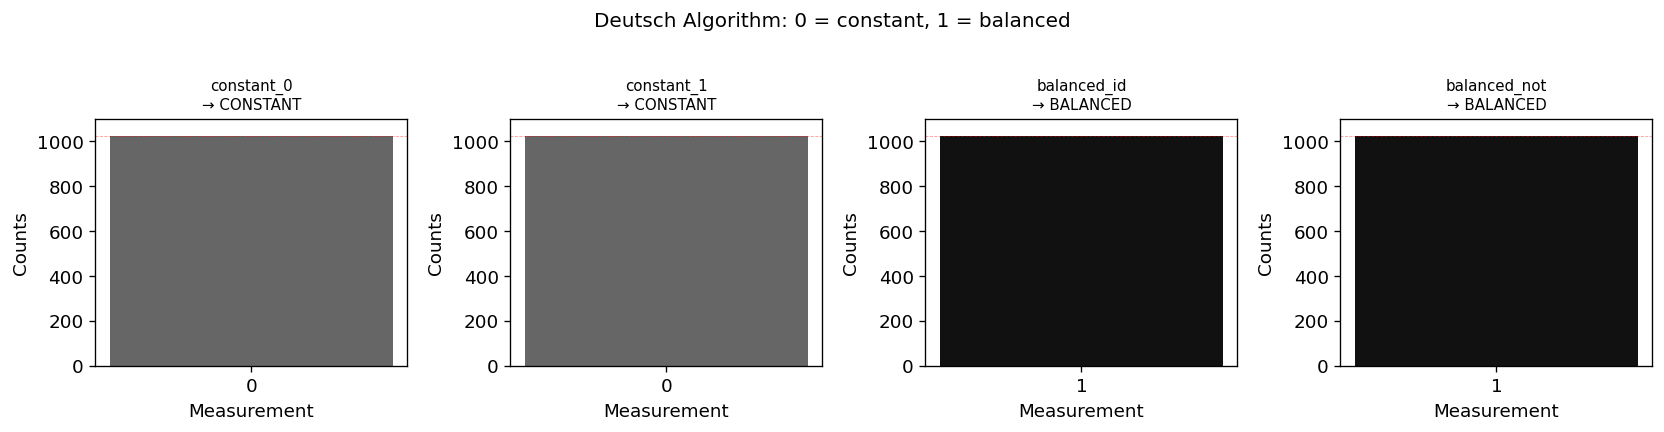


Interpretation:
  Measure |0⟩ → function is CONSTANT
  Measure |1⟩ → function is BALANCED
  Always deterministic in 1 query.


In [3]:
# ── Run all four oracles ──────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
oracle_types = ['constant_0', 'constant_1', 'balanced_id', 'balanced_not']

for ax, otype in zip(axes, oracle_types):
    qc = deutsch_circuit(otype)
    t_qc = transpile(qc, simulator)
    result = simulator.run(t_qc, shots=1024).result()
    counts = result.get_counts()

    is_constant = 'constant' in otype
    ax.bar(list(counts.keys()), list(counts.values()),
           color='#111' if not is_constant else '#666', width=0.4)
    ax.set_title(f"{otype}\n→ {'CONSTANT' if is_constant else 'BALANCED'}", fontsize=9)
    ax.set_xlabel("Measurement")
    ax.set_ylabel("Counts")
    ax.set_ylim(0, 1100)
    ax.axhline(1024, color='red', lw=0.5, ls='--', alpha=0.4)

plt.suptitle("Deutsch Algorithm: 0 = constant, 1 = balanced", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('deutsch_results.png', dpi=120, bbox_inches='tight')
plt.show()
print("\nInterpretation:")
print("  Measure |0⟩ → function is CONSTANT")
print("  Measure |1⟩ → function is BALANCED")
print("  Always deterministic in 1 query.")


## Deutsch-Jozsa Algorithm (n qubits)

The generalisation to $n$ input qubits is direct. The circuit is:

$$|0\rangle^{\otimes n}|1\rangle \xrightarrow{H^{\otimes(n+1)}} \frac{1}{\sqrt{2^n}}\sum_{x=0}^{2^n-1}|x\rangle |-\rangle \xrightarrow{U_f} \frac{1}{\sqrt{2^n}}\sum_x (-1)^{f(x)}|x\rangle |-\rangle \xrightarrow{H^{\otimes n}} \cdots$$

After the final layer of Hadamards, the amplitude of the all-zeros state $|0\rangle^{\otimes n}$ is:

$$\alpha_{0\ldots 0} = \frac{1}{2^n}\sum_{x=0}^{2^n-1}(-1)^{f(x)}$$

- **Constant**: all terms have the same sign → $|\alpha_{0\ldots0}|^2 = 1$. We measure $|0\rangle^{\otimes n}$ with certainty.
- **Balanced**: half are $+1$, half are $-1$ → they cancel completely, $\alpha_{0\ldots 0} = 0$. We **never** measure all zeros.

One query, no probability of error. Classical randomised algorithms need $O(1)$ queries with bounded error, but Deutsch-Jozsa is deterministic.


In [4]:
# ── Deutsch-Jozsa circuit for n input qubits ────────────────────────
def dj_oracle(oracle_type, n):
    """
    oracle_type: 'constant_0' | 'constant_1' | 'balanced'
    n: number of input qubits  (ancilla is qubit n)
    """
    qc = QuantumCircuit(n + 1, name=f"DJ Oracle ({oracle_type}, n={n})")

    if oracle_type == 'constant_0':
        pass                                    # f = 0 everywhere
    elif oracle_type == 'constant_1':
        qc.x(n)                                 # f = 1 everywhere
    elif oracle_type == 'balanced':
        # XOR of all input bits → exactly balanced
        for i in range(n):
            qc.cx(i, n)
    return qc

def dj_circuit(oracle_type, n=3):
    qc = QuantumCircuit(n + 1, n)

    # |0...0⟩|1⟩
    qc.x(n)
    qc.barrier()

    # H on all qubits
    qc.h(range(n + 1))
    qc.barrier()

    # Oracle
    qc.compose(dj_oracle(oracle_type, n), inplace=True)
    qc.barrier()

    # H on input register
    qc.h(range(n))
    qc.barrier()

    # Measure input qubits
    qc.measure(range(n), range(n))
    return qc

# Show 3-qubit circuit
print("Deutsch-Jozsa (n=3, balanced oracle):")
print(dj_circuit('balanced', n=3).draw('text'))


Deutsch-Jozsa (n=3, balanced oracle):
           ░ ┌───┐ ░                 ░ ┌───┐ ░ ┌─┐      
q_0: ──────░─┤ H ├─░───■─────────────░─┤ H ├─░─┤M├──────
           ░ ├───┤ ░   │             ░ ├───┤ ░ └╥┘┌─┐   
q_1: ──────░─┤ H ├─░───┼────■────────░─┤ H ├─░──╫─┤M├───
           ░ ├───┤ ░   │    │        ░ ├───┤ ░  ║ └╥┘┌─┐
q_2: ──────░─┤ H ├─░───┼────┼────■───░─┤ H ├─░──╫──╫─┤M├
     ┌───┐ ░ ├───┤ ░ ┌─┴─┐┌─┴─┐┌─┴─┐ ░ └───┘ ░  ║  ║ └╥┘
q_3: ┤ X ├─░─┤ H ├─░─┤ X ├┤ X ├┤ X ├─░───────░──╫──╫──╫─
     └───┘ ░ └───┘ ░ └───┘└───┘└───┘ ░       ░  ║  ║  ║ 
c: 3/═══════════════════════════════════════════╩══╩══╩═
                                                0  1  2 


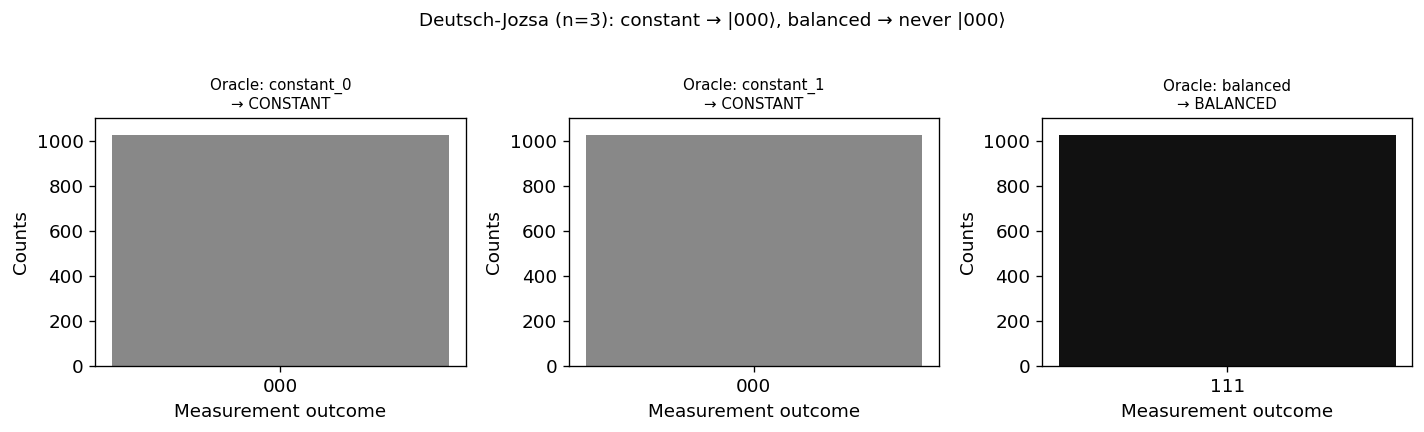


Constant: always measure |000⟩
Balanced: never measure |000⟩  (all amplitudes cancel)


In [5]:
# ── Run DJ for n = 3 ─────────────────────────────────────────────
n = 3
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

for ax, otype in zip(axes, ['constant_0', 'constant_1', 'balanced']):
    qc = dj_circuit(otype, n=n)
    t_qc = transpile(qc, simulator)
    result = simulator.run(t_qc, shots=1024).result()
    counts = result.get_counts()
    label = "CONSTANT" if 'constant' in otype else "BALANCED"

    ax.bar(list(counts.keys()), list(counts.values()),
           color='#111' if 'balanced' in otype else '#888', width=0.6)
    ax.set_title(f"Oracle: {otype}\n→ {label}", fontsize=9)
    ax.set_xlabel("Measurement outcome")
    ax.set_ylabel("Counts")
    ax.set_ylim(0, 1100)

plt.suptitle("Deutsch-Jozsa (n=3): constant → |000⟩, balanced → never |000⟩", fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('dj_results.png', dpi=120, bbox_inches='tight')
plt.show()
print("\nConstant: always measure |000⟩")
print("Balanced: never measure |000⟩  (all amplitudes cancel)")


In [6]:
# ── DJ scales to any n — show that it still uses one query ───────────
print("Query count comparison:\n")
print(f"{'n (input bits)':>18} | {'Classical (worst)':>18} | {'Quantum':>8}")
print("-" * 52)
for n in [1, 2, 3, 4, 5, 8, 10, 20]:
    classical = 2**(n-1) + 1
    print(f"{n:>18} | {classical:>18,} | {'1':>8}")


Query count comparison:

    n (input bits) |  Classical (worst) |  Quantum
----------------------------------------------------
                 1 |                  2 |        1
                 2 |                  3 |        1
                 3 |                  5 |        1
                 4 |                  9 |        1
                 5 |                 17 |        1
                 8 |                129 |        1
                10 |                513 |        1
                20 |            524,289 |        1


## Key Takeaways

1. **Phase kickback** is the core quantum trick: set the ancilla to $|-\rangle$, and the oracle writes $f(x)$ as a phase on the input.
2. **Interference** does the computation: the final Hadamard layer adds/cancels amplitudes to give a deterministic answer.
3. **Exponential separation** in query complexity: classical needs $O(2^n)$ queries; quantum needs exactly 1.
4. **Limitation**: Deutsch-Jozsa is artificial. Real-world problems are not promised to be exactly constant or balanced. Bernstein-Vazirani (next step) and Simon's problem give more practical separations.
5. The same phase kickback idea appears in **Grover** (next notebook) and **Shor** (following notebook).
